# PINN — 2D Navier-Stokes (Cylinder Wake)

비압축성 Navier-Stokes PDE (Raissi et al., 2019):

$$\frac{\partial u}{\partial t} + \lambda_1\!\left(u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y}\right) = -\frac{\partial p}{\partial x} + \lambda_2\!\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

$$\frac{\partial v}{\partial t} + \lambda_1\!\left(u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y}\right) = -\frac{\partial p}{\partial y} + \lambda_2\!\left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)$$

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0 \quad \text{(연속 방정식)}$$

$\lambda_1 = 1,\ \lambda_2 = 0.01\,(\nu = 1/Re,\ Re=100)$

**데이터**: `cylinder_nektar_wake.mat` — Nektar++ 수치 시뮬레이션 결과  

In [21]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [22]:
import torch
import torch.nn as nn
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pinns import PINN

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Data Loading

In [23]:
data   = sio.loadmat("cylinder_nektar_wake.mat")
X_star = data["X_star"].astype(np.float32)   # (5000, 2): [x, y]
t_star = data["t"].astype(np.float32)         # (200, 1):  time
U_star = data["U_star"].astype(np.float32)   # (5000, 2, 200): [u, v]
p_star = data["p_star"].astype(np.float32)   # (5000, 200): pressure

N_pts, N_t = X_star.shape[0], t_star.shape[0]

print(f"Spatial points : {N_pts},  Time steps : {N_t}")
print(f"x range : [{X_star[:,0].min():.3f}, {X_star[:,0].max():.3f}]")
print(f"y range : [{X_star[:,1].min():.3f}, {X_star[:,1].max():.3f}]")
print(f"t range : [{t_star.min():.3f}, {t_star.max():.3f}]")
print(f"u range : [{U_star[:,0,:].min():.3f}, {U_star[:,0,:].max():.3f}]")
print(f"v range : [{U_star[:,1,:].min():.3f}, {U_star[:,1,:].max():.3f}]")
print(f"p range : [{p_star.min():.3f}, {p_star.max():.3f}]")

Spatial points : 5000,  Time steps : 200
x range : [1.000, 8.000]
y range : [-2.000, 2.000]
t range : [0.000, 19.900]
u range : [-0.240, 1.323]
v range : [-0.624, 0.623]
p range : [-0.536, 0.072]


## 2. Training Data Preparation

In [24]:
# Flatten all points across time
x_all = np.tile(X_star[:, 0:1], (1, N_t)).flatten()[:, None]   # (1e6, 1)
y_all = np.tile(X_star[:, 1:2], (1, N_t)).flatten()[:, None]
t_all = np.tile(t_star.T,       (N_pts, 1)).flatten()[:, None]
u_all = U_star[:, 0, :].flatten()[:, None]
v_all = U_star[:, 1, :].flatten()[:, None]
p_all = p_star.flatten()[:, None]

N_total = len(x_all)
print(f"Total data points: {N_total:,}")

# Random subsample for training
N_data = 2500
idx = np.random.choice(N_total, N_data, replace=False)

xyt_data_np = np.hstack([x_all[idx], y_all[idx], t_all[idx]])  # (N_data, 3)
uv_data_np  = np.hstack([u_all[idx], v_all[idx]])               # (N_data, 2)

xyt_data = torch.tensor(xyt_data_np, dtype=torch.float32, device=device)
uv_data  = torch.tensor(uv_data_np,  dtype=torch.float32, device=device)

print(f"Training data  : {xyt_data.shape}")
print(f"Labels (u, v)  : {uv_data.shape}")

Total data points: 1,000,000
Training data  : torch.Size([2500, 3])
Labels (u, v)  : torch.Size([2500, 2])


## 3. NS PDE Residual

In [26]:
LAMBDA1 = 1.0    # inertia coefficient  (= rho)
LAMBDA2 = 0.01   # kinematic viscosity  (= 1/Re, Re=100)


def ns_residual(uvp: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """
    Incompressible Navier-Stokes residuals.

    Parameters
    ----------
    uvp : [N, 3]  model output (u, v, p), computed from x with create_graph.
    x   : [N, 3]  input (x, y, t), requires_grad=True.

    Returns
    -------
    [N, 3]  residuals [e_momentum_x, e_momentum_y, e_continuity]
    """
    u, v, p = uvp[:, 0:1], uvp[:, 1:2], uvp[:, 2:3]

    def D(f):
        """Full gradient of scalar field f w.r.t. x (create_graph for 2nd derivs)."""
        return torch.autograd.grad(
            f, x, grad_outputs=torch.ones_like(f), create_graph=True
        )[0]  # [N, 3]: ∂f/∂x, ∂f/∂y, ∂f/∂t

    du = D(u);  u_x, u_y, u_t = du[:, 0:1], du[:, 1:2], du[:, 2:3]
    dv = D(v);  v_x, v_y, v_t = dv[:, 0:1], dv[:, 1:2], dv[:, 2:3]
    dp = D(p);  p_x, p_y      = dp[:, 0:1], dp[:, 1:2]

    # 2nd-order spatial derivatives
    u_xx = D(u_x)[:, 0:1];  u_yy = D(u_y)[:, 1:2]
    v_xx = D(v_x)[:, 0:1];  v_yy = D(v_y)[:, 1:2]

    # x-momentum
    e_u = u_t + LAMBDA1 * (u * u_x + v * u_y) + p_x - LAMBDA2 * (u_xx + u_yy)
    # y-momentum
    e_v = v_t + LAMBDA1 * (u * v_x + v * v_y) + p_y - LAMBDA2 * (v_xx + v_yy)
    # continuity (incompressibility)
    e_c = u_x + v_y

    return torch.cat([e_u, e_v, e_c], dim=-1)   # [N, 3]

## 4. Model & Training

- **입력** : $(x, y, t)$ — 3차원  
- **출력** : $(u, v, p)$ — 3차원 (압력은 비지도 복원)  
- **손실** : $\mathcal{L} = w_{\text{data}}\,\|\hat{u}-u\|^2 + w_{\text{data}}\,\|\hat{v}-v\|^2 + w_{\text{pde}}\,\|\mathbf{e}_{\text{NS}}\|^2$

In [27]:
model = PINN(
    layers=[3, 128, 128, 128, 128, 3],   # 3 in: (x,y,t) → 3 out: (u,v,p)
    activation="tanh",
    residual=False,
    skip=True,
    use_fourier=False,
    use_ntk=False,
).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 100,099


In [15]:
EPOCHS    = 20000
LR        = 1e-3
W_DATA    = 1.0
W_PDE     = 1.0
LOG_EVERY = 100
SAVE_PATH = "./best_ns.pt"

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[10000], gamma=0.5
)

loss_history = {"total": [], "data": [], "pde": []}
best_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()

    # Enable grad on input for PDE autograd
    x_ = xyt_data.clone().requires_grad_(True)

    # --- Single forward pass ---
    uvp = model(x_)                              # [N, 3]

    # --- Data loss : supervise u, v only ---
    loss_data = nn.functional.mse_loss(uvp[:, 0:2], uv_data)

    # --- PDE loss : NS + continuity ---
    res      = ns_residual(uvp, x_)              # [N, 3]
    loss_pde = (res ** 2).mean()

    total = W_DATA * loss_data + W_PDE * loss_pde

    optimizer.zero_grad()
    total.backward()
    optimizer.step()
    scheduler.step()

    # --- History & best model ---
    loss_history["total"].append(total.item())
    loss_history["data"].append(loss_data.item())
    loss_history["pde"].append(loss_pde.item())

    if total.item() < best_loss:
        best_loss = total.item()
        torch.save(model.state_dict(), SAVE_PATH)

    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(
            f"[{epoch:>6}/{EPOCHS}]  "
            f"Total: {total.item():.3e}  "
            f"Data: {loss_data.item():.3e}  "
            f"PDE: {loss_pde.item():.3e}  "
            f"lr: {scheduler.get_last_lr()[0]:.1e}"
        )

model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
print(f"\nTraining complete. Best total loss: {best_loss:.3e}")

[     1/20000]  Total: 5.049e-01  Data: 5.044e-01  PDE: 5.153e-04  lr: 1.0e-03
[   100/20000]  Total: 7.380e-02  Data: 7.343e-02  PDE: 3.703e-04  lr: 1.0e-03
[   200/20000]  Total: 4.494e-02  Data: 4.379e-02  PDE: 1.158e-03  lr: 1.0e-03
[   300/20000]  Total: 3.614e-02  Data: 3.479e-02  PDE: 1.348e-03  lr: 1.0e-03
[   400/20000]  Total: 3.259e-02  Data: 3.135e-02  PDE: 1.243e-03  lr: 1.0e-03
[   500/20000]  Total: 2.986e-02  Data: 2.869e-02  PDE: 1.170e-03  lr: 1.0e-03
[   600/20000]  Total: 2.724e-02  Data: 2.601e-02  PDE: 1.227e-03  lr: 1.0e-03
[   700/20000]  Total: 2.625e-02  Data: 2.519e-02  PDE: 1.061e-03  lr: 1.0e-03
[   800/20000]  Total: 2.400e-02  Data: 2.279e-02  PDE: 1.214e-03  lr: 1.0e-03
[   900/20000]  Total: 2.394e-02  Data: 2.284e-02  PDE: 1.102e-03  lr: 1.0e-03
[  1000/20000]  Total: 2.116e-02  Data: 1.991e-02  PDE: 1.245e-03  lr: 1.0e-03
[  1100/20000]  Total: 1.979e-02  Data: 1.858e-02  PDE: 1.216e-03  lr: 1.0e-03
[  1200/20000]  Total: 1.801e-02  Data: 1.672e-02  P

## 5. Loss History

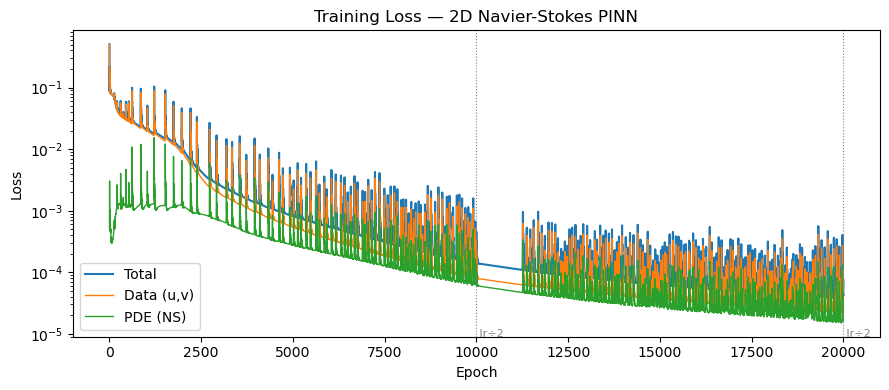

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(loss_history["total"], label="Total",   lw=1.5)
ax.semilogy(loss_history["data"],  label="Data (u,v)", lw=1)
ax.semilogy(loss_history["pde"],   label="PDE (NS)",   lw=1)
ax.axvline(10000, color="gray", lw=0.8, linestyle=":")
ax.axvline(20000, color="gray", lw=0.8, linestyle=":")
ax.text(10000, ax.get_ylim()[0], " lr÷2", fontsize=8, color="gray")
ax.text(20000, ax.get_ylim()[0], " lr÷2", fontsize=8, color="gray")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Loss — 2D Navier-Stokes PINN")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Snapshot Evaluation: PINN vs. Ground Truth

특정 시각 $t^*$에서 전체 2500개 공간 점에 대해 예측

Snapshot at t = 4.0000  (index 40)


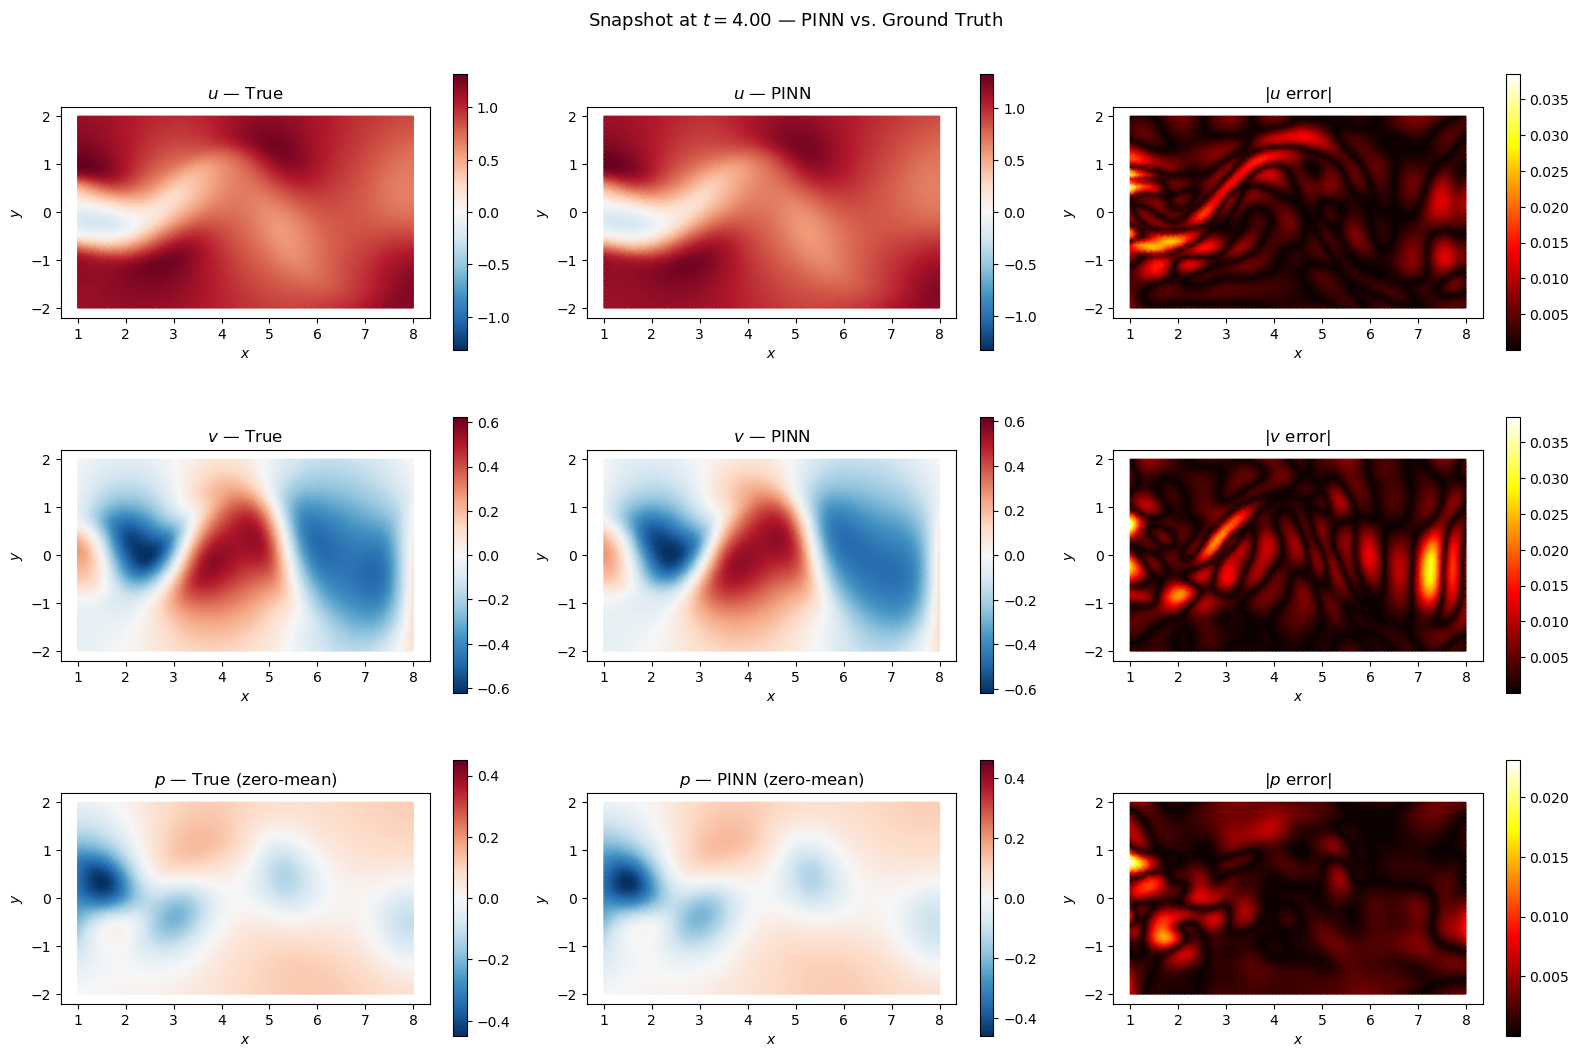

Relative L2 error  u : 5.7259e-03
Relative L2 error  v : 2.1577e-02
Relative L2 error  p : 2.7465e-02  (zero-mean)


In [17]:
T_SNAP = 4.0   # snapshot time (must be within t_star range)
t_idx  = int(np.argmin(np.abs(t_star.ravel() - T_SNAP)))
t_val  = float(t_star[t_idx, 0])
print(f"Snapshot at t = {t_val:.4f}  (index {t_idx})")

# Build input: all 5000 spatial points at t_val
xyt_snap = np.hstack([X_star, np.full((N_pts, 1), t_val, dtype=np.float32)])
xyt_snap_t = torch.tensor(xyt_snap, dtype=torch.float32, device=device)

model.eval()
with torch.no_grad():
    uvp_pred = model(xyt_snap_t).cpu().numpy()   # (5000, 3)

u_pred = uvp_pred[:, 0];  v_pred = uvp_pred[:, 1];  p_pred = uvp_pred[:, 2]
u_true = U_star[:, 0, t_idx]
v_true = U_star[:, 1, t_idx]
p_true = p_star[:, t_idx]

# Zero-mean pressure for fair comparison (pressure is gauge-free)
p_pred_z = p_pred - p_pred.mean()
p_true_z = p_true - p_true.mean()

# Delaunay triangulation of scattered points for plotting
triang = mtri.Triangulation(X_star[:, 0], X_star[:, 1])

def triplot(ax, values, title, cmap="RdBu_r", sym=True):
    vabs = np.abs(values).max() if sym else None
    vmin, vmax = (-vabs, vabs) if sym else (values.min(), values.max())
    tc = ax.tripcolor(triang, values, cmap=cmap, vmin=vmin, vmax=vmax, shading="gouraud")
    ax.set_title(title); ax.set_aspect("equal")
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    plt.colorbar(tc, ax=ax, shrink=0.8)

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle(f"Snapshot at $t = {t_val:.2f}$ — PINN vs. Ground Truth", fontsize=13)

triplot(axes[0,0], u_true,              "$u$ — True")
triplot(axes[0,1], u_pred,              "$u$ — PINN")
triplot(axes[0,2], np.abs(u_pred-u_true), "$|u$ error$|$", cmap="hot", sym=False)

triplot(axes[1,0], v_true,              "$v$ — True")
triplot(axes[1,1], v_pred,              "$v$ — PINN")
triplot(axes[1,2], np.abs(v_pred-v_true), "$|v$ error$|$", cmap="hot", sym=False)

triplot(axes[2,0], p_true_z,            "$p$ — True (zero-mean)")
triplot(axes[2,1], p_pred_z,            "$p$ — PINN (zero-mean)")
triplot(axes[2,2], np.abs(p_pred_z-p_true_z), "$|p$ error$|$", cmap="hot", sym=False)

plt.tight_layout()
plt.show()

# Relative L2 errors
def rel_l2(pred, true):
    return np.linalg.norm(pred - true) / (np.linalg.norm(true) + 1e-10)

print(f"Relative L2 error  u : {rel_l2(u_pred, u_true):.4e}")
print(f"Relative L2 error  v : {rel_l2(v_pred, v_true):.4e}")
print(f"Relative L2 error  p : {rel_l2(p_pred_z, p_true_z):.4e}  (zero-mean)")

## 7. Vorticity $\omega = \partial v/\partial x - \partial u/\partial y$

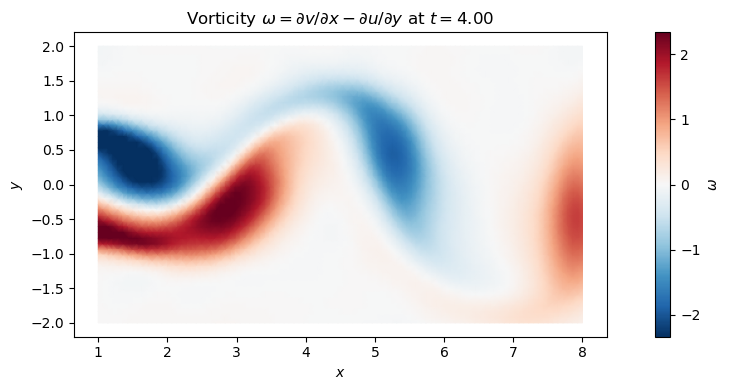

In [19]:
xyt_snap_grad = torch.tensor(
    xyt_snap, dtype=torch.float32, device=device, requires_grad=True
)
model.eval()
uvp_snap = model(xyt_snap_grad)

u_s = uvp_snap[:, 0:1]
v_s = uvp_snap[:, 1:2]

u_grad = torch.autograd.grad(
    u_s, xyt_snap_grad, grad_outputs=torch.ones_like(u_s), retain_graph=True
)[0]
v_grad = torch.autograd.grad(
    v_s, xyt_snap_grad, grad_outputs=torch.ones_like(v_s)
)[0]

u_y = u_grad[:, 1].detach().cpu().numpy()
v_x = v_grad[:, 0].detach().cpu().numpy()
vorticity = v_x - u_y   # ω = ∂v/∂x - ∂u/∂y

fig, ax = plt.subplots(figsize=(10, 4))
vabs = np.percentile(np.abs(vorticity), 98)
tc = ax.tripcolor(triang, vorticity, cmap="RdBu_r", vmin=-vabs, vmax=vabs, shading="gouraud")
ax.set_title(f"Vorticity $\\omega = \\partial v/\\partial x - \\partial u/\\partial y$ at $t={t_val:.2f}$")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_aspect("equal")
plt.colorbar(tc, ax=ax, label="$\\omega$")
plt.tight_layout()
plt.show()

## 8. Error Summary Across All Time Steps

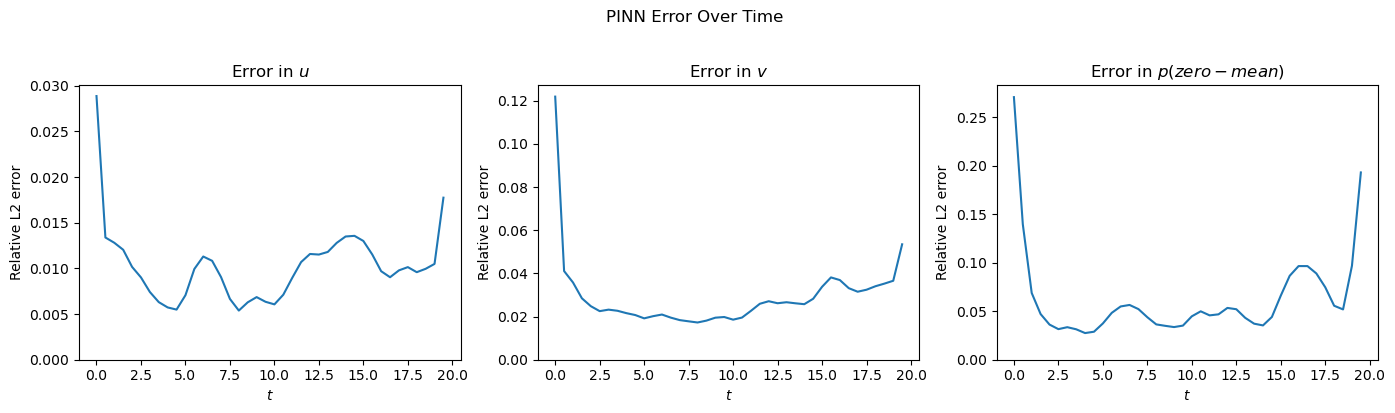

Mean rel-L2  u : 1.0237e-02
Mean rel-L2  v : 2.9125e-02
Mean rel-L2  p : 6.2658e-02


In [20]:
err_u_list, err_v_list, err_p_list = [], [], []

model.eval()
STRIDE = 5   # evaluate every 5 time steps (adjust for speed)

with torch.no_grad():
    for ti in range(0, N_t, STRIDE):
        t_v = float(t_star[ti, 0])
        xyt_i = np.hstack([X_star, np.full((N_pts, 1), t_v, dtype=np.float32)])
        xyt_t = torch.tensor(xyt_i, dtype=torch.float32, device=device)
        pred  = model(xyt_t).cpu().numpy()

        u_t = U_star[:, 0, ti];  v_t = U_star[:, 1, ti];  p_t = p_star[:, ti]
        p_pr = pred[:, 2] - pred[:, 2].mean()
        p_tr = p_t - p_t.mean()

        err_u_list.append(rel_l2(pred[:, 0], u_t))
        err_v_list.append(rel_l2(pred[:, 1], v_t))
        err_p_list.append(rel_l2(p_pr, p_tr))

t_eval = t_star[::STRIDE, 0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, err, lbl in zip(axes,
                        [err_u_list, err_v_list, err_p_list],
                        ["u", "v", "p (zero-mean)"]):
    ax.plot(t_eval, err, lw=1.5)
    ax.set_xlabel("$t$"); ax.set_ylabel("Relative L2 error")
    ax.set_title(f"Error in ${lbl}$")
    ax.set_ylim(bottom=0)

plt.suptitle("PINN Error Over Time", y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean rel-L2  u : {np.mean(err_u_list):.4e}")
print(f"Mean rel-L2  v : {np.mean(err_v_list):.4e}")
print(f"Mean rel-L2  p : {np.mean(err_p_list):.4e}")